# Train Schedule Analysis and Interactive Route Enquiry System
## Project Objective

This project analyzes train schedules and provides an interactive
route enquiry system using Python, Pandas and data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\Shivank Tiwari\OneDrive\Desktop\project
['Dataset1.csv', 'Train_Schedule_Analysis_and_Interactive_Route_Enquiry_System.ipynb', 'Verified_Train_Schedule_Dataset.csv']


In [3]:
import pandas as pd

df = pd.read_csv("Dataset1.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 186074
Columns: 12


# Level 1: Basic Data Review

## Task 1.1: Overview of Dataset

The objective of this task is to understand the size and structure
of the train schedule dataset by identifying the total number of
records and attributes.

In [4]:
# Task 1.1: Dataset Overview

print("TRAIN SCHEDULE DATASET OVERVIEW")
print("=" * 40)

print("Total Records:", df.shape[0])
print("Total Attributes:", df.shape[1])

print("\nDataset Shape:", df.shape)

TRAIN SCHEDULE DATASET OVERVIEW
Total Records: 186074
Total Attributes: 12

Dataset Shape: (186074, 12)


In [5]:
print("Attributes in the Dataset:")
print("=" * 40)

for i, column in enumerate(df.columns, start=1):
    print(i, ".", column)
    

Attributes in the Dataset:
1 . SN
2 . Train_No
3 . Station_Code
4 . 1A
5 . 2A
6 . 3A
7 . SL
8 . Station_Name
9 . Route_Number
10 . Arrival_time
11 . Departure_Time
12 . Distance


## Task 1.2: Starting and Ending Stations

This task identifies the starting and ending station of every train
in the dataset.

In [6]:
# Sort data by train number and route number

train_data = df.sort_values(
    ["Train_No", "Route_Number"]
)

# Get starting station of each train
starting_stations = (
    train_data
    .groupby("Train_No")
    .first()
    [["Station_Code", "Station_Name"]]
    .rename(columns={
        "Station_Code": "Starting_Station_Code",
        "Station_Name": "Starting_Station"
    })
)

# Get ending station of each train
ending_stations = (
    train_data
    .groupby("Train_No")
    .last()
    [["Station_Code", "Station_Name"]]
    .rename(columns={
        "Station_Code": "Ending_Station_Code",
        "Station_Name": "Ending_Station"
    })
)

# Combine both
train_routes = starting_stations.join(ending_stations)

#pd.set_option("display.max_rows", None)# to remove the limit

train_routes.head(20)

,Starting_Station_Code,Starting_Station,Ending_Station_Code,Ending_Station
Train_No,,,,
107,SWV,SAWANTWADI R,MAO,MADGOAN JN.
108,MAO,MADGOAN JN.,SWV,SAWANTWADI R
128,MAO,MADGOAN JN.,KOP,CHHATRAPATI
290,DSJ,DELHI-SAFDAR,DSJ,DELHI-SAFDAR
401,AWB,AURANGABAD,BSB,VARANASI JN.
421,LKO,LUCKNOW JN.,SVDK,SHRI MATA VA
422,SVDK,SHRI MATA VA,LKO,LUCKNOW JN.
477,SSA,SIRSA,SSA,SIRSA
502,RJPB,RAJENDRANAGA,UMB,AMBALA CANTT


## Task 1.3: Number of Stops per Train

This task calculates the total number of stations or stops
served by each train.

In [7]:
# Calculate number of stops for each train

stops_per_train = (
    df.groupby("Train_No")
    .size()
    .reset_index(name="Number_of_Stops")
)

stops_per_train.head(20)

,Train_No,Number_of_Stops
0,107,4
1,108,4
2,128,22
3,290,14
4,401,12
5,421,5
6,422,5
7,477,14
8,502,9
9,504,3


## Task 1.4: Trains with Maximum and Minimum Stops

This task identifies the trains having the maximum and minimum
number of stops.

In [8]:
# Maximum number of stops
max_stops = stops_per_train["Number_of_Stops"].max()

# Minimum number of stops
min_stops = stops_per_train["Number_of_Stops"].min()

print("Maximum Number of Stops:", max_stops)
print("Minimum Number of Stops:", min_stops)
# Trains with maximum stops

maximum_stop_trains = stops_per_train[
    stops_per_train["Number_of_Stops"] == max_stops
]

print("Trains with Maximum Stops:")
display(maximum_stop_trains)
# Trains with minimum stops

minimum_stop_trains = stops_per_train[
    stops_per_train["Number_of_Stops"] == min_stops
]

print("Trains with Minimum Stops:")
display(minimum_stop_trains)

# Total number of trains
total_trains = len(minimum_stop_trains)

print("Minimum number of stops:", min_stops)
print("Total trains with minimum stops:", total_trains)

pd.reset_option("display.max_rows")

minimum_stop_trains.head(20)

Maximum Number of Stops: 118
Minimum Number of Stops: 2
Trains with Maximum Stops:


,Train_No,Number_of_Stops
5977,53041,118


Trains with Minimum Stops:


,Train_No,Number_of_Stops
11,557,2
53,3305,2
54,3306,2
105,5715,2
106,5716,2
...,...,...
11064,99499,2
11065,99500,2
11066,99501,2
11067,99502,2


Minimum number of stops: 2
Total trains with minimum stops: 1249


,Train_No,Number_of_Stops
11,557,2
53,3305,2
54,3306,2
105,5715,2
106,5716,2
220,8001,2
221,8002,2
250,8581,2
251,8582,2
479,12049,2


# Level 2: Simple Data Processing

In this level, the train schedule dataset will be processed to make the data more useful for analysis.

The main objectives are:

1. Standardize arrival and departure times.
2. Calculate the total journey duration for each train.
3. Classify train routes as Short, Medium, or Long.
4. Calculate the train frequency for each station.

These steps will help prepare the dataset for further data quality checks, analysis, and visualization.

## Task 2.1: Standardize Arrival and Departure Times

In this task, arrival and departure times are converted into a standard HH:MM format.

In [9]:
# Task 2.1: Standardize Arrival and Departure Times

# Convert the arrival time column into datetime format
df["Arrival_time"] = pd.to_datetime(
    df["Arrival_time"],
    format="%H:%M",
    errors="coerce"
)

# Convert the departure time column into datetime format
df["Departure_Time"] = pd.to_datetime(
    df["Departure_Time"],
    format="%H:%M",
    errors="coerce"
)

# Keep only hours and minutes in HH:MM format
df["Arrival_time"] = df["Arrival_time"].dt.strftime("%H:%M")
df["Departure_Time"] = df["Departure_Time"].dt.strftime("%H:%M")

# Display the first 10 records with standardized time columns
df[["Train_No", "Station_Name", "Arrival_time", "Departure_Time"]].head(20)

,Train_No,Station_Name,Arrival_time,Departure_Time
0,107,SAWANTWADI R,NaN,NaN
1,107,THIVIM,NaN,NaN
2,107,KARMALI,NaN,NaN
3,107,MADGOAN JN.,NaN,NaN
4,108,MADGOAN JN.,NaN,NaN
5,108,KARMALI,NaN,NaN
6,108,THIVIM,NaN,NaN
7,108,SAWANTWADI R,NaN,NaN
8,128,MADGOAN JN.,NaN,NaN
9,128,KARMALI,NaN,NaN


## Task 2.2: Calculate Total Journey Duration

In this task, the total journey duration of each train is calculated using its first departure time and last arrival time.

In [10]:
# Task 2.2: Calculate Total Journey Duration for Each Train

# Reload the original dataset to restore the original time values
df = pd.read_csv("Dataset1.csv")

# Display the original time values for verification
print("Original Arrival and Departure Times:")
display(df[["Train_No", "Arrival_time", "Departure_Time"]].head(10))

# Convert time values into minutes after midnight
def convert_time_to_minutes(value):
    value = str(value).strip()

    if ":" in value:
        hours, minutes = value.split(":")[:2]
        return int(hours) * 60 + int(minutes)

    value = value.zfill(4)
    hours = int(value[:2])
    minutes = int(value[2:])

    return hours * 60 + minutes

# Convert arrival and departure times into minutes
df["Arrival_Minutes"] = df["Arrival_time"].apply(convert_time_to_minutes)
df["Departure_Minutes"] = df["Departure_Time"].apply(convert_time_to_minutes)

# Get the first departure and last arrival time for each train
journey_duration = df.groupby("Train_No").agg(
    First_Departure=("Departure_Minutes", "first"),
    Last_Arrival=("Arrival_Minutes", "last")
).reset_index()

# Calculate journey duration
journey_duration["Journey_Duration_Minutes"] = (
    journey_duration["Last_Arrival"]
    - journey_duration["First_Departure"]
)

# Add 24 hours when the journey crosses midnight
journey_duration.loc[
    journey_duration["Journey_Duration_Minutes"] < 0,
    "Journey_Duration_Minutes"
] += 24 * 60

# Convert minutes into hours and minutes
journey_duration["Journey_Duration"] = pd.to_timedelta(
    journey_duration["Journey_Duration_Minutes"],
    unit="m"
)

# Display the first 20 train journey durations
journey_duration[
    [
        "Train_No",
        "First_Departure",
        "Last_Arrival",
        "Journey_Duration"
    ]
].head(20)

Original Arrival and Departure Times:


,Train_No,Arrival_time,Departure_Time
0,107,00:00:00,10:25:00
1,107,11:06:00,11:08:00
2,107,11:28:00,11:30:00
3,107,12:10:00,00:00:00
4,108,00:00:00,20:30:00
5,108,21:04:00,21:06:00
6,108,21:26:00,21:28:00
7,108,22:25:00,00:00:00
8,128,19:40:00,19:40:00
9,128,20:18:00,20:20:00


,Train_No,First_Departure,Last_Arrival,Journey_Duration
0,107,625,730,0 days 01:45:00
1,108,1230,1345,0 days 01:55:00
2,128,1180,1065,0 days 22:05:00
3,290,1110,150,0 days 08:00:00
4,401,1290,600,0 days 12:30:00
5,421,1380,480,0 days 09:00:00
6,422,705,870,0 days 02:45:00
7,477,730,920,0 days 03:10:00
8,502,630,570,0 days 23:00:00
9,504,540,600,0 days 01:00:00


## Task 2.3: Classify Routes

In this task, train routes are classified into three categories: Short, Medium, and Long.

The classification is based on the total journey duration of each train.

In [11]:
# Task 2.3: Classify Train Routes

# Convert journey duration into total minutes
journey_duration["Duration_Minutes"] = (
    journey_duration["Journey_Duration_Minutes"]
)

# Define a function to classify routes based on journey duration
def classify_route(duration):
    if duration <= 180:
        return "Short"
    elif duration <= 480:
        return "Medium"
    else:
        return "Long"

# Apply the classification function to every train
journey_duration["Route_Type"] = (
    journey_duration["Duration_Minutes"].apply(classify_route)
)

# Display the first 20 classified train routes
journey_duration[
    [
        "Train_No",
        "Journey_Duration",
        "Duration_Minutes",
        "Route_Type"
    ]
].head(20)

,Train_No,Journey_Duration,Duration_Minutes,Route_Type
0,107,0 days 01:45:00,105,Short
1,108,0 days 01:55:00,115,Short
2,128,0 days 22:05:00,1325,Long
3,290,0 days 08:00:00,480,Medium
4,401,0 days 12:30:00,750,Long
5,421,0 days 09:00:00,540,Long
6,422,0 days 02:45:00,165,Short
7,477,0 days 03:10:00,190,Medium
8,502,0 days 23:00:00,1380,Long
9,504,0 days 01:00:00,60,Short


## Task 2.4: Station-wise Train Frequency Counts

In this task, the number of unique trains passing through each station is calculated.

The results help identify stations with high and low train frequency.

In [12]:
# Task 2.4: Station-wise Train Frequency Counts

# Count unique trains at each station
station_frequency = (
    df.groupby(["Station_Code", "Station_Name"])["Train_No"]
    .nunique()
    .reset_index(name="Train_Frequency")
)

# Sort stations by train frequency in descending order
station_frequency = station_frequency.sort_values(
    by="Train_Frequency",
    ascending=False
)

# Display the first 20 stations with the highest train frequency
station_frequency.head(20)

,Station_Code,Station_Name,Train_Frequency
1713,CSMT,CST-MUMBAI,1027
4254,KYN,KALYAN JN,828
7602,TNA,THANE,796
6649,SDAH,SEALDAH,745
5030,MSB,CHENNAI BEAC,738
2979,HWH,HOWRAH JN.,699
2130,DR,DADAR,567
1843,DDJ,DUM DUM JN.,463
1592,CLA,KURLA,462
7395,TBM,TAMBARAM,434


# Level 3: Data Quality Checks

In this level, the train schedule dataset will be checked and cleaned to improve data quality.

The main objectives are:

1. Handle missing schedule values.
2. Remove duplicate train records.
3. Verify the correct station order for each train.
4. Save the verified and cleaned dataset.

## Task 3.1: Handle Missing Schedule Values

In this task, missing values in important schedule columns are identified and handled.

In [13]:
# Task 3.1: Handle Missing Schedule Values

# Check missing values in each column
missing_values = df.isnull().sum()

# Display missing values
print("Missing Values Before Cleaning:")
display(missing_values)

# Remove records with missing train numbers or station names
df = df.dropna(
    subset=["Train_No", "Station_Code", "Station_Name"]
)

# Fill missing arrival and departure times with a placeholder
df["Arrival_time"] = df["Arrival_time"].fillna("00:00")
df["Departure_Time"] = df["Departure_Time"].fillna("00:00")

# Check missing values after cleaning
print("Missing Values After Cleaning:")
display(df.isnull().sum())

Missing Values Before Cleaning:


SN                   0
Train_No             0
Station_Code         0
1A                   0
2A                   0
3A                   0
SL                   0
Station_Name         0
Route_Number         0
Arrival_time         0
Departure_Time       0
Distance             0
Arrival_Minutes      0
Departure_Minutes    0
dtype: int64

Missing Values After Cleaning:


SN                   0
Train_No             0
Station_Code         0
1A                   0
2A                   0
3A                   0
SL                   0
Station_Name         0
Route_Number         0
Arrival_time         0
Departure_Time       0
Distance             0
Arrival_Minutes      0
Departure_Minutes    0
dtype: int64

##### Report ######
### Observation

The dataset contained no missing values in any column. Therefore, no records were removed or replaced during the missing-value handling process.

## Task 3.2: Remove Duplicate Train Records

In this task, duplicate records are identified and removed from the train schedule dataset.

In [14]:
# Task 3.2: Remove Duplicate Train Records

# Count duplicate records before cleaning
duplicate_count_before = df.duplicated().sum()

print("Duplicate Records Before Cleaning:", duplicate_count_before)

# Remove duplicate records
df = df.drop_duplicates().reset_index(drop=True)

# Count duplicate records after cleaning
duplicate_count_after = df.duplicated().sum()

print("Duplicate Records After Cleaning:", duplicate_count_after)

# Display the updated dataset shape
print("Updated Dataset Shape:", df.shape)

Duplicate Records Before Cleaning: 0
Duplicate Records After Cleaning: 0
Updated Dataset Shape: (186074, 14)


## Task 3.3: Verify Correct Station Order

In this task, the station order of each train is verified using the distance values.

A train route is considered consistent when its station distances follow one direction, either increasing or decreasing.

In [15]:
# Task 3.3: Verify Correct Station Order

# Preserve the original row order of the dataset
df["_Original_Order"] = range(len(df))

# Sort the data by train number and original dataset order
route_check = df.sort_values(
    by=["Train_No", "_Original_Order"]
).copy()

# Calculate the distance difference between consecutive stations
route_check["Distance_Change"] = (
    route_check.groupby("Train_No")["Distance"].diff()
)

# Create a function to verify station order
def verify_station_order(distance_changes):
    changes = distance_changes.dropna()

    # Remove zero changes because the distance is unchanged
    changes = changes[changes != 0]

    # A train with fewer than two distance changes cannot be verified
    if len(changes) == 0:
        return "Insufficient Data"

    # Check whether all distance changes are positive
    if (changes > 0).all():
        return "Correct - Increasing Distance"

    # Check whether all distance changes are negative
    if (changes < 0).all():
        return "Correct - Decreasing Distance"

    # Mixed changes indicate a possible station-order issue
    return "Check Required"

# Apply the verification function to every train
station_order_check = (
    route_check.groupby("Train_No")["Distance_Change"]
    .apply(verify_station_order)
    .reset_index(name="Station_Order_Status")
)

# Display the station-order verification results
display(station_order_check.head(20))

# Count the results of the verification
print("Station Order Verification Summary:")
display(station_order_check["Station_Order_Status"].value_counts())

,Train_No,Station_Order_Status
0,107,Correct - Increasing Distance
1,108,Correct - Increasing Distance
2,128,Correct - Increasing Distance
3,290,Correct - Increasing Distance
4,401,Correct - Increasing Distance
5,421,Correct - Increasing Distance
6,422,Correct - Increasing Distance
7,477,Correct - Increasing Distance
8,502,Correct - Increasing Distance
9,504,Correct - Increasing Distance


Station Order Verification Summary:


Station_Order_Status
Correct - Increasing Distance    11113
Name: count, dtype: int64

In [16]:
# Display trains that require manual station-order inspection

problematic_trains = station_order_check[
    station_order_check["Station_Order_Status"] == "Check Required"
]

print("Trains Requiring Manual Inspection:")
display(problematic_trains)

Trains Requiring Manual Inspection:


,Train_No,Station_Order_Status


## Task 3.4: Save Verified Dataset

In this task, the cleaned and verified train schedule dataset is saved as a CSV file for further analysis.

In [17]:
# Task 3.4: Save the verified dataset

# Remove temporary helper columns
df = df.drop(  
    columns=["_Original_Order"],
    errors="ignore"
)

# Save the cleaned and verified dataset
df.to_csv(
    "Verified_Train_Schedule_Dataset.csv",
    index=False
)

print("Verified dataset saved successfully.")
print("File Name: Verified_Train_Schedule_Dataset.csv")
print("Final Dataset Shape:", df.shape)

Verified dataset saved successfully.
File Name: Verified_Train_Schedule_Dataset.csv
Final Dataset Shape: (186074, 14)


# Level 4: Basic Analysis & Visualization

In this level, the cleaned train schedule dataset will be analyzed using basic statistical methods and visualizations.

The main objectives are:

1. Compare average journey durations across route types.
2. Identify high-traffic stations.
3. Create visualizations for journey duration and station traffic.
4. Summarize the key observations from the analysis.

## Task 4.1: Average Journey Duration by Route Type

In this task, the average journey duration of Short, Medium, and Long routes is calculated and compared.

In [18]:
# Task 4.1: Compare Average Journey Durations Across Route Types

# Calculate the average journey duration for each route type
average_duration_by_route = (
    journey_duration.groupby("Route_Type")["Duration_Minutes"]
    .mean()
    .reset_index(name="Average_Duration_Minutes")
)

# Sort the results by average duration
average_duration_by_route = average_duration_by_route.sort_values(
    by="Average_Duration_Minutes"
)

# Display the average journey duration
print("Average Journey Duration by Route Type:")
display(average_duration_by_route)

Average Journey Duration by Route Type:


,Route_Type,Average_Duration_Minutes
2,Short,80.284636
1,Medium,303.798223
0,Long,855.955252


In [19]:
# Convert average journey duration from minutes to hours

average_duration_by_route["Average_Duration_Hours"] = (
    average_duration_by_route["Average_Duration_Minutes"] / 60
)

# Display the final comparison table
display(average_duration_by_route)

,Route_Type,Average_Duration_Minutes,Average_Duration_Hours
2,Short,80.284636,1.338077
1,Medium,303.798223,5.063304
0,Long,855.955252,14.265921


### Observation

The average journey duration was calculated for Short, Medium, and Long route categories. The results show the difference in travel time among the three route types.

## Task 4.2: Identify High-Traffic Stations

In this task, stations with the highest number of unique trains are identified.

These stations are considered high-traffic stations based on train frequency.

In [20]:
# Task 4.2: Identify High-Traffic Stations

# Sort stations by train frequency in descending order
high_traffic_stations = station_frequency.sort_values(
    by="Train_Frequency",
    ascending=False
)

# Display the top 20 high-traffic stations
print("Top 20 High-Traffic Stations:")
display(high_traffic_stations.head(20))

Top 20 High-Traffic Stations:


,Station_Code,Station_Name,Train_Frequency
1713,CSMT,CST-MUMBAI,1027
4254,KYN,KALYAN JN,828
7602,TNA,THANE,796
6649,SDAH,SEALDAH,745
5030,MSB,CHENNAI BEAC,738
2979,HWH,HOWRAH JN.,699
2130,DR,DADAR,567
1843,DDJ,DUM DUM JN.,463
1592,CLA,KURLA,462
7395,TBM,TAMBARAM,434


### Observation

The high-traffic stations were identified by counting the number of unique trains passing through each station. The stations with the highest train frequency were displayed for further analysis.

## Task 4.3: Basic Visualizations

In this task, basic charts are created to visualize journey duration and station-wise train frequency.

These visualizations make it easier to understand the distribution of train journey durations and identify high-traffic stations.

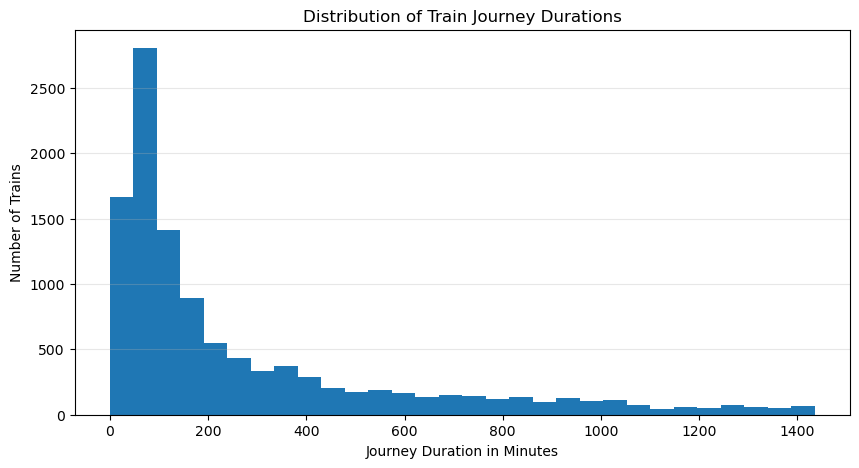

In [21]:
# Task 4.3: Journey Duration Visualization

import matplotlib.pyplot as plt

# Create a histogram of journey durations
plt.figure(figsize=(10, 5))

plt.hist(
    journey_duration["Duration_Minutes"],
    bins=30
)

plt.title("Distribution of Train Journey Durations")
plt.xlabel("Journey Duration in Minutes")
plt.ylabel("Number of Trains")

plt.grid(axis="y", alpha=0.3)
plt.show()

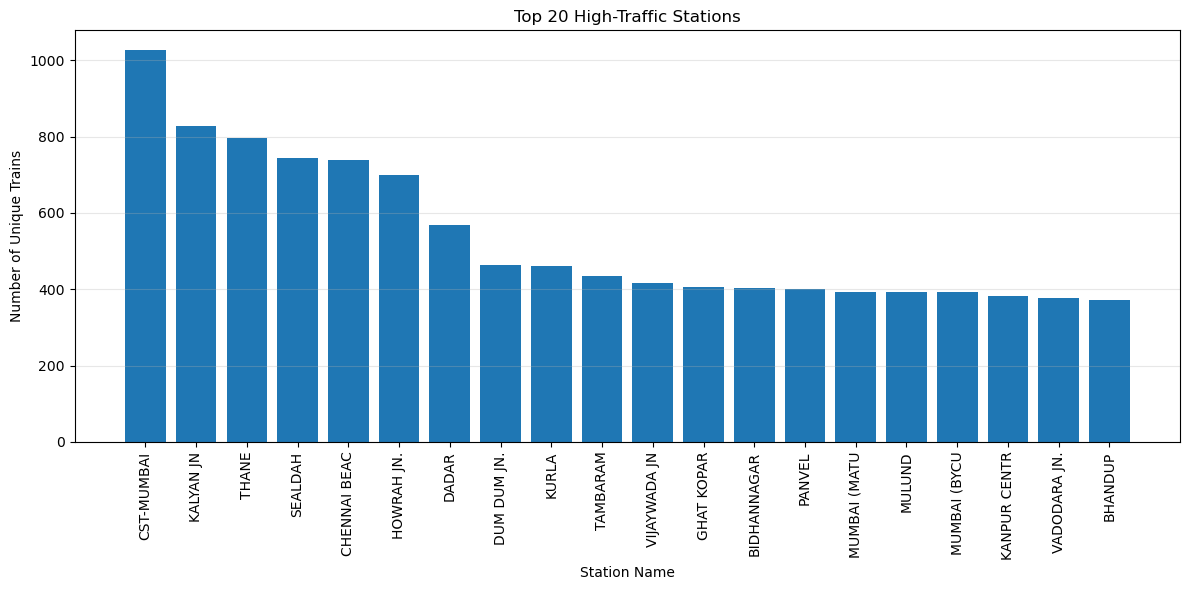

In [22]:
# Task 4.3: Station Traffic Visualization

# Select the top 20 high-traffic stations
top_20_stations = station_frequency.head(20)

# Create a bar chart
plt.figure(figsize=(12, 6))

plt.bar(
    top_20_stations["Station_Name"],
    top_20_stations["Train_Frequency"]
)

plt.title("Top 20 High-Traffic Stations")
plt.xlabel("Station Name")
plt.ylabel("Number of Unique Trains")

# Rotate station names for better readability
plt.xticks(rotation=90)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

The journey duration histogram shows the distribution of train journey durations in the dataset.

The station traffic bar chart displays the top 20 stations with the highest number of unique trains. These stations can be considered high-traffic stations based on train frequency.

## Task 4.4: Summary of Key Observations

The following observations were identified from the train schedule analysis:

1. The average journey duration was calculated for Short, Medium, and Long route categories.
2. High-traffic stations were identified using the number of unique trains passing through each station.
3. The journey duration histogram helped visualize the distribution of train journey durations.
4. The station traffic bar chart displayed the top 20 stations with the highest train frequency.
5. The analysis provides a basic understanding of train journey durations and station-wise train frequency.

In [23]:
# Task 4.4: Display Key Analysis Results

# Display average journey duration by route type
print("Average Journey Duration by Route Type:")
display(average_duration_by_route)

# Display the top 10 high-traffic stations
print("Top 10 High-Traffic Stations:")
display(high_traffic_stations.head(10))

# Display the total number of trains and stations
print("Total Number of Trains:", df["Train_No"].nunique())
print("Total Number of Stations:", df["Station_Code"].nunique())

Average Journey Duration by Route Type:


,Route_Type,Average_Duration_Minutes,Average_Duration_Hours
2,Short,80.284636,1.338077
1,Medium,303.798223,5.063304
0,Long,855.955252,14.265921


Top 10 High-Traffic Stations:


,Station_Code,Station_Name,Train_Frequency
1713,CSMT,CST-MUMBAI,1027
4254,KYN,KALYAN JN,828
7602,TNA,THANE,796
6649,SDAH,SEALDAH,745
5030,MSB,CHENNAI BEAC,738
2979,HWH,HOWRAH JN.,699
2130,DR,DADAR,567
1843,DDJ,DUM DUM JN.,463
1592,CLA,KURLA,462
7395,TBM,TAMBARAM,434


Total Number of Trains: 11113
Total Number of Stations: 8147


## Task 5.1: Create a Pivot Table

A pivot table is used to summarize and analyze data.

In this task, we will calculate the number of unique trains operating at each station.

In [24]:
# Task 5.1: Create a Pivot Table

# Create a pivot table showing the number of unique trains at each station
pivot_station_train = pd.pivot_table(
    df,
    index="Station_Name",
    values="Train_No",
    aggfunc=pd.Series.nunique
).reset_index()

# Rename the Train_No column
pivot_station_train = pivot_station_train.rename(
    columns={"Train_No": "Unique_Train_Count"}
)

# Sort stations according to the number of unique trains
pivot_station_train = pivot_station_train.sort_values(
    by="Unique_Train_Count",
    ascending=False
)

# Display the top 20 stations
display(pivot_station_train.head(20))

,Station_Name,Unique_Train_Count
1755,CST-MUMBAI,1027
3466,KALYAN JN,828
7509,THANE,796
6834,SEALDAH,745
1592,CHENNAI BEAC,738
2950,HOWRAH JN.,699
1773,DADAR,598
2213,DUM DUM JN.,463
4245,KURLA,462
7401,TAMBARAM,434


## Task 5.2: Create a Cross-Tabulation

Cross-tabulation is used to compare two categorical variables.

In this task, we will compare route types with the number of trains.

In [25]:
# Task 5.2: Create a Cross-Tabulation

# Count unique trains in each route type
route_type_train_count = (
    journey_duration.groupby("Route_Type")["Train_No"]
    .nunique()
    .reset_index(name="Train_Count")
)

# Display the result
display(route_type_train_count)

,Route_Type,Train_Count
0,Long,2123
1,Medium,2364
2,Short,6626


## Task 5.3: Create Comparative Charts

Comparative charts help us compare the number of trains and average journey duration across different route types.

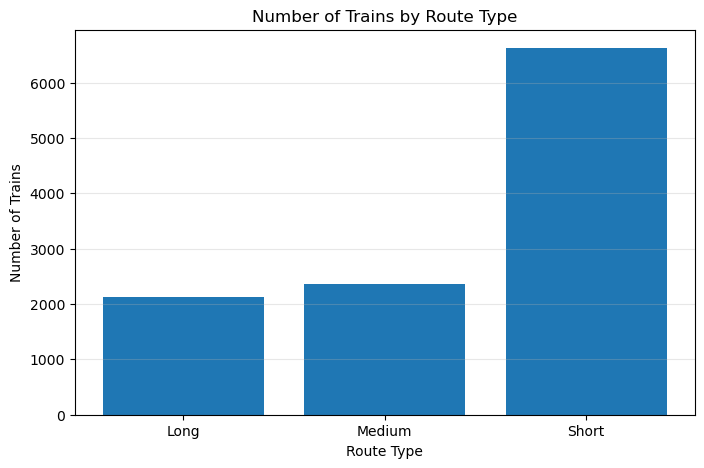

In [26]:
# Task 5.3: Compare the number of trains by route type

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    route_type_train_count["Route_Type"],
    route_type_train_count["Train_Count"]
)

plt.title("Number of Trains by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Number of Trains")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [27]:
# Convert average journey duration from minutes into hours

average_duration_by_route["Average_Duration_Hours"] = (
    average_duration_by_route["Average_Duration_Minutes"] / 60
)

display(average_duration_by_route)

,Route_Type,Average_Duration_Minutes,Average_Duration_Hours
2,Short,80.284636,1.338077
1,Medium,303.798223,5.063304
0,Long,855.955252,14.265921


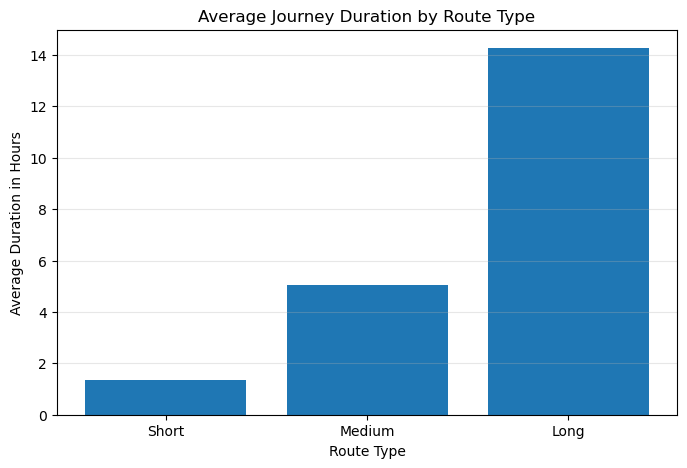

In [28]:
# Compare average journey duration by route type

plt.figure(figsize=(8, 5))

plt.bar(
    average_duration_by_route["Route_Type"],
    average_duration_by_route["Average_Duration_Hours"]
)

plt.title("Average Journey Duration by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Average Duration in Hours")
plt.grid(axis="y", alpha=0.3)

plt.show()

## Task 5.4: Advanced Insights

The advanced analysis identifies high-traffic stations, train distribution by route type, and differences in average journey duration.

These insights help in understanding railway network activity and route patterns.

In [29]:
# Task 5.4: Display advanced analysis results

print("Top 10 Stations Based on Unique Train Count:")
display(pivot_station_train.head(10))

print("Train Count by Route Type:")
display(route_type_train_count)

print("Average Journey Duration by Route Type:")
display(average_duration_by_route)

Top 10 Stations Based on Unique Train Count:


,Station_Name,Unique_Train_Count
1755,CST-MUMBAI,1027
3466,KALYAN JN,828
7509,THANE,796
6834,SEALDAH,745
1592,CHENNAI BEAC,738
2950,HOWRAH JN.,699
1773,DADAR,598
2213,DUM DUM JN.,463
4245,KURLA,462
7401,TAMBARAM,434


Train Count by Route Type:


,Route_Type,Train_Count
0,Long,2123
1,Medium,2364
2,Short,6626


Average Journey Duration by Route Type:


,Route_Type,Average_Duration_Minutes,Average_Duration_Hours
2,Short,80.284636,1.338077
1,Medium,303.798223,5.063304
0,Long,855.955252,14.265921


In [30]:
# Display important findings from the analysis

top_station = pivot_station_train.iloc[0]

most_common_route = route_type_train_count.loc[
    route_type_train_count["Train_Count"].idxmax()
]

longest_average_route = average_duration_by_route.loc[
    average_duration_by_route["Average_Duration_Minutes"].idxmax()
]

print("Advanced Analysis Summary")
print("-------------------------")

print(
    "Highest-traffic station:",
    top_station["Station_Name"],
    "| Unique trains:",
    top_station["Unique_Train_Count"]
)

print(
    "Route type with the highest number of trains:",
    most_common_route["Route_Type"],
    "| Train count:",
    most_common_route["Train_Count"]
)

print(
    "Route type with the highest average journey duration:",
    longest_average_route["Route_Type"],
    "| Average duration:",
    round(longest_average_route["Average_Duration_Hours"], 2),
    "hours"
)

Advanced Analysis Summary
-------------------------
Highest-traffic station: CST-MUMBAI | Unique trains: 1027
Route type with the highest number of trains: Short | Train count: 6626
Route type with the highest average journey duration: Long | Average duration: 14.27 hours


# Level 6: Final Capstone System

## Interactive Route Enquiry System

This system allows users to enter a source station and destination station.

The system searches the train schedule and displays:
- Available direct trains
- Source station
- Destination station
- Estimated journey duration

The system is being developed as a prototype for passenger use.

In [31]:
#  Load the dataset

import pandas as pd

df = pd.read_csv("Dataset1.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 186074
Columns: 12


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [32]:
#  Convert time into minutes

def convert_time_to_minutes(value):
    value = str(value).strip()

    if ":" in value:
        hours, minutes = value.split(":")[:2]
        return int(hours) * 60 + int(minutes)

    value = value.zfill(4)

    hours = int(value[:2])
    minutes = int(value[2:])

    return hours * 60 + minutes


df["Arrival_Minutes"] = df["Arrival_time"].apply(
    convert_time_to_minutes
)

df["Departure_Minutes"] = df["Departure_Time"].apply(
    convert_time_to_minutes
)

display(
    df[
        [
            "Train_No",
            "Station_Name",
            "Arrival_time",
            "Departure_Time",
            "Arrival_Minutes",
            "Departure_Minutes"
        ]
    ].head(10)
)

,Train_No,Station_Name,Arrival_time,Departure_Time,Arrival_Minutes,Departure_Minutes
0,107,SAWANTWADI R,00:00:00,10:25:00,0,625
1,107,THIVIM,11:06:00,11:08:00,666,668
2,107,KARMALI,11:28:00,11:30:00,688,690
3,107,MADGOAN JN.,12:10:00,00:00:00,730,0
4,108,MADGOAN JN.,00:00:00,20:30:00,0,1230
5,108,KARMALI,21:04:00,21:06:00,1264,1266
6,108,THIVIM,21:26:00,21:28:00,1286,1288
7,108,SAWANTWADI R,22:25:00,00:00:00,1345,0
8,128,MADGOAN JN.,19:40:00,19:40:00,1180,1180
9,128,KARMALI,20:18:00,20:20:00,1218,1220


##  Route Enquiry Function

The function accepts a source station and destination station.

It searches each train and checks whether both stations are available in the correct order.

If a direct route is found, the system displays the train number and estimated journey duration.

In [ ]:


def route_enquiry(source, destination):

    source = source.strip().lower()
    destination = destination.strip().lower()

    results = []

    for train_no, train_data in df.groupby("Train_No", sort=False):

        train_data = train_data.reset_index(drop=True)

        station_names = (
            train_data["Station_Name"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        source_rows = train_data[
            station_names == source
        ]

        destination_rows = train_data[
            station_names == destination
        ]

        # Check whether both stations are available
        if source_rows.empty or destination_rows.empty:
            continue

        source_index = source_rows.index[0]
        destination_index = destination_rows.index[0]

        # Destination must come after source
        if source_index >= destination_index:
            continue

        source_row = source_rows.iloc[0]
        destination_row = destination_rows.iloc[0]

        # Calculate journey duration
        duration = (
            destination_row["Arrival_Minutes"]
            - source_row["Departure_Minutes"]
        )

        # Handle journey crossing midnight
        if duration < 0:
            duration += 1440

        hours = duration // 60
        minutes = duration % 60

        results.append({
            "Train No": train_no,
            "Source": source_row["Station_Name"],
            "Departure": source_row["Departure_Time"],
            "Destination": destination_row["Station_Name"],
            "Arrival": destination_row["Arrival_time"],
            "Journey Duration":
                f"{int(hours)} hours {int(minutes)} minutes"
        })

    result = pd.DataFrame(results)

    if result.empty:

        print("No direct train found for this route.")

    else:

        display(result)

    return result

In [40]:
#  Test the route enquiry system

source = input("Enter source station: ")
destination = input("Enter destination station: ")

route_results = route_enquiry(
    source,
    destination
)

,Train No,Source,Departure,Destination,Arrival,Journey Duration
0,1011,THANE,01:10:00,KALYAN JN,01:32:00,0 hours 22 minutes
1,11007,THANE,07:35:00,KALYAN JN,07:52:00,0 hours 17 minutes
2,11009,THANE,15:05:00,KALYAN JN,15:27:00,0 hours 22 minutes
3,11011,THANE,12:33:00,KALYAN JN,12:52:00,0 hours 19 minutes
4,11013,THANE,22:55:00,KALYAN JN,23:15:00,0 hours 20 minutes
...,...,...,...,...,...,...
151,97147,THANE,22:53:00,KALYAN JN,23:26:00,0 hours 33 minutes
152,97149,THANE,23:01:00,KALYAN JN,23:34:00,0 hours 33 minutes
153,97151,THANE,23:12:00,KALYAN JN,23:45:00,0 hours 33 minutes
154,97153,THANE,23:20:00,KALYAN JN,23:53:00,0 hours 33 minutes
